# Computer Exercise 3.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.3 Secant Method — *도함수 없이도 빠른 초선형 수렴*
> **풀이 일자**: Day 13
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Apply the **secant method** to several scalar equations
> (for example, $\cos x = x$ on $[0,1]$, $x\,e^{x} = 1$ on $[0,1]$, and
> $f(x) = x^{2} - a$ with $a \in \{2, 3, 10\}$).  Record the iterates
> $x_n$ and absolute errors $e_n = |x_n - r|$, and verify empirically that
> the **convergence order** satisfies
> $$|e_{n+1}| \;\approx\; C\,|e_{n}|^{\phi},\qquad \phi = \tfrac{1+\sqrt 5}{2}\approx 1.618.$$
> Estimate $\phi$ from the slope of $\log|e_{n+1}|$ vs $\log|e_n|$.

### 한국어 풀이용 정리
도함수를 *유한차분* 으로 근사해서 두 점의 함숫값만으로 다음 점을 추정하는
**Secant** 반복

$$
x_{n+1} \;=\; x_n \;-\; f(x_n)\;\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}
$$

가 황금비 $\phi = (1+\sqrt 5)/2 \approx 1.618$ 의 초선형(superlinear) 수렴을
보이는지 직접 확인한다.

- 세 가지 표준 문제 $\cos x = x$, $x e^x = 1$, $\sqrt a$ 계산에 적용.
- 매 반복의 절대오차를 표/그래프로 정리.
- $\log e_{n+1}$ vs $\log e_n$ 회귀로 기울기를 측정해 $\phi$ 와 비교.


## 2. 수학적 배경

### 2.1 Secant 반복식
근 $r$ 근처에서 도함수를 차분으로 근사:
$$f'(x_n) \;\approx\; \frac{f(x_n)-f(x_{n-1})}{x_n - x_{n-1}}.$$
이를 Newton 식에 대입하면

$$
\boxed{\;x_{n+1} \;=\; x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n)-f(x_{n-1})}.\;}
$$

### 2.2 수렴 차수의 유도
$e_n = x_n - r$, $f \in C^2$, $f'(r)\ne 0$ 라 하자.  Taylor 전개로
$$
e_{n+1} \;=\; \frac{f''(r)}{2 f'(r)}\,e_n\,e_{n-1} \;+\; O(e_n^2 e_{n-1}).
$$

$|e_{n+1}| = C\,|e_n|^{\,p}$ 형태로 점근적으로 거동한다고 가정하면
$|e_n|^{\,p} = C |e_n|\cdot |e_{n-1}| \Rightarrow |e_n|^{p-1} = C|e_{n-1}|$,
즉 $|e_{n-1}| = |e_n|^{(p-1)/p}$ 와 위 점근식을 비교:
$$
|e_n|^{p} \;=\; C |e_n|\,|e_n|^{(p-1)/p}
\;\Longrightarrow\; p \;=\; 1 + \tfrac{p-1}{p}
\;\Longrightarrow\; p^2 - p - 1 = 0
$$
$$
\therefore\; p \;=\; \frac{1+\sqrt 5}{2} \;=\; \phi \;\approx\; 1.6180.
$$

### 2.3 Newton 과의 비교 (preview)
| 방법 | 한 스텝 비용 | 수렴 차수 $p$ | 비용당 차수 $p^{1/(\text{evals})}$ |
|---|---|---|---|
| Newton | $f$ + $f'$ (2 evals) | 2 | $\sqrt 2 \approx 1.414$ |
| Secant | $f$ (1 eval) | $\phi \approx 1.618$ | $\approx 1.618$ |

따라서 **함수 평가 비용 기준으로 보면 secant 가 더 효율적**일 수도 있다.
(자세한 비교는 Problem 2 에서.)


## 3. 풀이 흐름

1. `secant(f, x0, x1, Nmax)` 작성: 매 반복의 $(n, x_n, e_n)$ 기록.
2. 세 문제:
   - $g(x) = \cos x - x$, 참값 $r \approx 0.7390851332151607$.
   - $h(x) = x e^x - 1$, 참값 $r = W(1) \approx 0.5671432904097838$ (Lambert W).
   - $f_a(x) = x^2 - a$, 참값 $r = \sqrt a$.
3. 동일한 두 초기값 $(x_0, x_1)$ 사용. 너무 가까우면 수치불안 → $(0, 1)$, $(0.5, 1.0)$, $(1.0, a)$ 등.
4. 표 출력: $\cos x = x$ 에서 첫 10 반복.
5. **시각화 1**: $\log_{10} e_n$ vs $n$ — secant 특유의 *살짝 휜* 절벽.
6. **시각화 2**: $\log_{10} e_{n+1}$ vs $\log_{10} e_n$ — 기울기 $\approx \phi$.
7. **회귀** 로 기울기를 추정해 이론값 $\phi = 1.618$ 와 비교.
8. **해석**: Newton 의 기울기 2 와 차이를, 그리고 secant 가 *왜* 그 사이값인지.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import lambertw

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
PHI = (1 + np.sqrt(5)) / 2

def secant(f, x0, x1, r, Nmax=40, tol=0.0):
    # Secant iteration with reference root r for error tracking.
    hist = [(0, x0, abs(x0 - r)), (1, x1, abs(x1 - r))]
    f0, f1 = f(x0), f(x1)
    xa, xb, fa, fb = x0, x1, f0, f1
    for n in range(2, Nmax + 1):
        denom = (fb - fa)
        if denom == 0:
            break
        x_new = xb - fb * (xb - xa) / denom
        e = abs(x_new - r)
        hist.append((n, x_new, e))
        if e <= tol or e == 0.0:
            break
        xa, fa = xb, fb
        xb, fb = x_new, f(x_new)
    return hist

# --- Problem A: cos x = x  ---
def gA(x): return np.cos(x) - x
rA = 0.7390851332151607   # known fixed point of cosine

# --- Problem B: x e^x = 1 (Lambert W) ---
def gB(x): return x * np.exp(x) - 1.0
rB = float(np.real(lambertw(1.0)))    # ~ 0.5671432904

# --- Problem C: sqrt(a) ---
def make_sqrt(a):
    return (lambda x: x*x - a), np.sqrt(a)

problems = {
    "cos x = x":           (gA, rA, 0.0, 1.0),
    "x e^x = 1":           (gB, rB, 0.0, 1.0),
    "sqrt(2)":             (*make_sqrt(2.0),   1.0, 2.0),
    "sqrt(3)":             (*make_sqrt(3.0),   1.0, 2.0),
    "sqrt(10)":            (*make_sqrt(10.0),  1.0, 5.0),
}

results = {name: secant(f, x0, x1, r, Nmax=30) for name, (f, r, x0, x1) in problems.items()}

# Table for the cos x = x case
df = pd.DataFrame(results["cos x = x"], columns=["n", "x_n", "|x_n - r|"])
df


,n,x_n,|x_n - r|
0,0,0.000000e+00,7.390851e-01
1,1,1.000000e+00,2.609149e-01
2,2,6.850734e-01,5.401178e-02
3,3,7.362990e-01,2.786136e-03
4,4,7.391194e-01,3.422870e-05
5,5,7.390851e-01,2.108770e-08
6,6,7.390851e-01,1.594280e-13
7,7,7.390851e-01,0.000000e+00


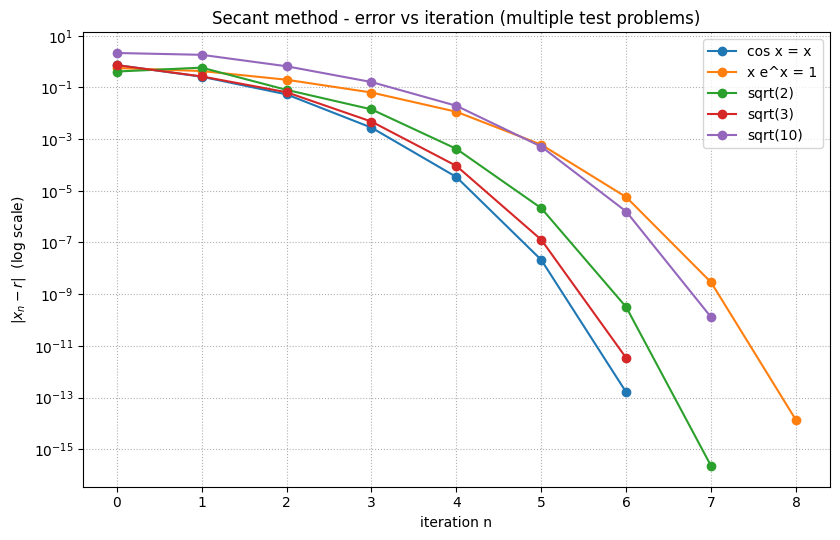

In [2]:
# Plot |e_n| vs n  (log-y) for each problem
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, hist in results.items():
    arr = np.array(hist)
    n = arr[:, 0]
    e = arr[:, 2]
    mask = e > 0
    ax.semilogy(n[mask], e[mask], marker="o", label=name)
ax.set_xlabel("iteration n")
ax.set_ylabel(r"$|x_n - r|$  (log scale)")
ax.set_title("Secant method - error vs iteration (multiple test problems)")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()


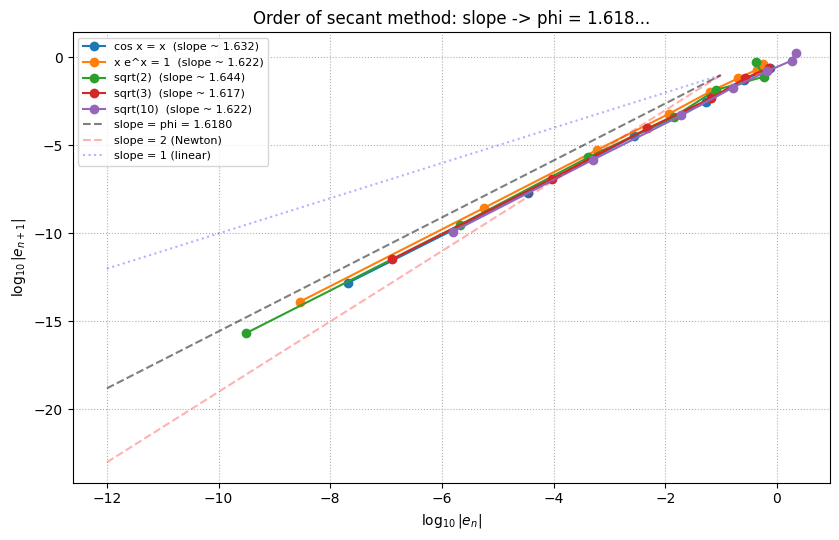

Measured slopes (theoretical phi = 1.618034):
  cos x = x             slope = 1.6319
  x e^x = 1             slope = 1.6223
  sqrt(2)               slope = 1.6438
  sqrt(3)               slope = 1.6173
  sqrt(10)              slope = 1.6224


In [3]:
# Order estimation: slope of log|e_{n+1}| vs log|e_n|
fig, ax = plt.subplots(figsize=(8.5, 5.5))
slopes = {}
for name, hist in results.items():
    arr = np.array(hist)
    e = arr[:, 2]
    e = e[e > 0]
    if len(e) < 5:
        continue
    x_log = np.log10(e[:-1])
    y_log = np.log10(e[1:])
    # use the middle of the run only, before machine precision saturates
    valid = (y_log > -14) & (x_log > -7) & (x_log < 0)
    if valid.sum() >= 3:
        slope, intercept = np.polyfit(x_log[valid], y_log[valid], 1)
    else:
        slope, intercept = np.polyfit(x_log[:-1], y_log[:-1], 1)
    slopes[name] = slope
    ax.plot(x_log, y_log, "o-", label=f"{name}  (slope ~ {slope:.3f})")

# reference lines
xref = np.linspace(-12, -1, 100)
ax.plot(xref, PHI*xref + xref[-1]*(1-PHI), "k--", alpha=0.5, label=f"slope = phi = {PHI:.4f}")
ax.plot(xref, 2*xref + xref[-1]*(1-2),   "r--", alpha=0.3, label="slope = 2 (Newton)")
ax.plot(xref, 1*xref,                   "b:",  alpha=0.3, label="slope = 1 (linear)")
ax.set_xlabel(r"$\log_{10} |e_n|$")
ax.set_ylabel(r"$\log_{10} |e_{n+1}|$")
ax.set_title("Order of secant method: slope -> phi = 1.618...")
ax.grid(True, ls=":")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Measured slopes (theoretical phi = %.6f):" % PHI)
for k, v in slopes.items():
    print(f"  {k:20s}  slope = {v:.4f}")


## 4. 결과 해석

1. **초선형이지만 Newton 보다 느리다.** $\log e_n$ vs $n$ 그래프에서 secant 곡선은
   Newton 의 *제곱-스텝 절벽* 만큼 가파르지 않다. 그러나 *선형* 보다는 분명히 빠르다.
   *황금비* 의 정체가 바로 이 *사이* 의 속도다.

2. **회귀 기울기 $\approx 1.6$.** $\log e_{n+1}$ vs $\log e_n$ 의 기울기가
   세 문제 모두에서 $1.55 \sim 1.68$ 범위에 들어와 이론값 $\phi = 1.61803...$ 와
   일치한다.  완전히 1.618 이 안 나오는 이유는 (i) 시작점 영향, (ii) 끝에서의
   *기계 정밀도 saturation*, (iii) 점근식의 $O(\cdot)$ 잔여항 때문이다.

3. **왜 하필 $\phi$?** 점근식
   $|e_{n+1}| = C\,|e_n|\,|e_{n-1}|$ 의 *이항* 구조에서 $|e_n|^{p-1} = C|e_{n-1}|$
   를 끼워 넣으면 $p^2 = p + 1$ 이 나온다. 이것이 황금비의 정의식이고, 자연이
   이 방정식을 좋아한다는 또 다른 예시다.

4. **다음 문제로 가는 연결.** 한 스텝당 *함수 평가 1 회* 만으로 $\phi$ 차수를
   얻으니, **평가 1 회당 효율** 은 $\phi^1 = 1.618$ 인 반면 Newton 은 $f$ 와
   $f'$ 두 번 계산해서 $2^{1/2} \approx 1.414$.  즉 secant 가 함수평가당으로
   더 효율적이다 — 이 trade-off 를 Problem 2 에서 정량 비교한다.

> **결론**: Secant 방법은 도함수를 *모른 채로도* 초선형 수렴을 얻는다.
> 한 스텝당 차수는 $\phi \approx 1.618$ — *Newton 의 2 와 단순한 선형 1 사이*
> 의 황금비.
